#Модели Тимура

##Простая модель для ансамбля


Простая cnn для бинарной классификации дипфейков
Одна из трёх моих моделей, предсказания которой вместе с остальными 6 моделями подаются на мета-модель в стекинге

Особенности:
- Архитектура с batchnorm для регуляризации и стабильности обучения
- Взвешенная crossentropy (1:3.5) для компенсации дисбаланса классов
- Ранняя остановка по f1-score
- SEED = 555

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
from torch.amp import GradScaler, autocast


!pip install gdown -q
import gdown
import zipfile

file_id = "1zKEj9mN1FJVtCqRCwCl1vBVTHonsw_cI"
url = f"https://drive.google.com/uc?id={file_id}"
output = "/content/ml-intensive.zip"
gdown.download(url, output, quiet=False)

with zipfile.ZipFile('/content/ml-intensive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

Downloading...
From (original): https://drive.google.com/uc?id=1zKEj9mN1FJVtCqRCwCl1vBVTHonsw_cI
From (redirected): https://drive.google.com/uc?id=1zKEj9mN1FJVtCqRCwCl1vBVTHonsw_cI&confirm=t&uuid=a447d34a-b367-4970-88fa-6636b78c56cf
To: /content/ml-intensive.zip
100%|██████████| 2.68G/2.68G [00:11<00:00, 243MB/s]


In [ ]:
# Загружаем таргеты из csv (0 — настоящие, 1 — дипфейки)
targets = pd.read_csv('/content/dataset/dataset/train_solution.csv', header=None)[1].values

class BaseDataset(Dataset):
    """
    Базовый датасет, подгружающий изображения по индексу и их метки
    Применяет аугментации
    """
    def __init__(self, img_dir, targets, transform=None):
        self.img_dir = img_dir
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.targets[idx], dtype=torch.long)

In [ ]:
# Индексы разбиения заранее зафиксированы
# train_idx — основная выборка для обучения и валидации
# holdout_idx — отложенная выборка для оценки ансамбля
train_idx = np.load('/content/train_idx.npy')
holdout_idx = np.load('/content/holdout_idx.npy')

In [ ]:
# Фиксируем seed для воспроизводимости
SEED = 555
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Простые трансформы: ресайз до 256x256 и горизонтальные отражения
# Отражения помогают модели не запоминать ориентацию объектов на изображении
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

# Для валидации и теста используем только ресайз, без изменений
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

class SimpleFakeDetector(nn.Module):
    """
    Свёрточная сеть из пяти блоков с увеличением числа фильтров: 32, 64, 128, 256, 512
    Каждый блок содержит два свёрточных слоя 3x3 с batchnorm и relu, затем maxpooling
    Batchnorm применяю для ускорения сходимости и в качестве лёгкой регуляризации,
    чтобы меньше полагаться на dropout внутри свёрточных блоков
    Финальная часть: global average pooling превращает карты признаков в вектор,
    после чего идут два полносвязных слоя с dropout и выход на 2 класса
    """
    def __init__(self, num_classes=2):
        super().__init__()

        # Feature-extractor: 5 блоков по 2 свертки, по 2 batchnorm и relu, затем maxpooling
        # Блок 1: вход 3 канала, выход 32 карты признаков
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Блок 2: вход 32 канала, выход 64 карты признаков
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Блок 3: вход 64 канала, выход 128 карт признаков
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Блок 4: вход 128 каналов, выход 256 карт признаков
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Блок 5: вход 256 каналов, выход 512 карт признаков
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Преобразует карты признаков в вектор размерностью 512 объектов
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # Классификатор: два скрытых слоя с dropout для снижения переобучения.
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    # Прямой проход по модели с моей архитектурой
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)

        return x

# Гиперпараметры для обучения
BATCH_SIZE = 128
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3

In [ ]:
# Полный датасет со всеми тренировочными картинками и метками
full_dataset = BaseDataset('/content/dataset/dataset/train_images', targets)

# Индексы предварительно зафиксированы, train_idx для обучения, holdout_idx для итоговой валидации ансамбля
train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
train_dataset.dataset.transform = train_transforms

holdout_dataset = torch.utils.data.Subset(full_dataset, holdout_idx)
holdout_dataset.dataset.transform = val_transforms

# Делим обучающую часть на train и val (90/10) с фиксированным seed для воспроизводимости
val_split = int(0.9 * len(train_dataset))
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [val_split, len(train_dataset) - val_split],
    generator=torch.Generator().manual_seed(SEED)
)

# num_workers=2 ускоряет загрузку данных, pin_memory=True улучшает скорость передачи на GPU
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
holdout_loader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

class TestDataset(Dataset):
    """Датасет для тестовых изображений без меток"""
    def __init__(self, img_dir, num_images, transform=None):
        self.img_dir = img_dir
        self.num_images = num_images
        self.transform = transform
    def __len__(self):
        return self.num_images
    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, f'{idx}.jpg'

num_test = 10000
test_dataset = TestDataset('/content/dataset/dataset/test_images', num_test,
                           transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, scaler):
    """
    Функция для обучения модели на одной эпохе
    Использую mixed precision для ускорения прохода
    и снижения расхода памяти посредством вычислений в float16
    Метрика качества — f1-score
    Возвращает средний loss и f1-score по всему датасету
    """
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for x, y in tqdm(loader, desc='Train'):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda'):
            output = model(x)
            loss = loss_fn(output, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    return total_loss / len(loader), f1

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    """
    Валидация или тест, без вычисления градиентов и обновлений весов
    Возвращает средний лосс и f1-score по всему датасету
    """
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    for x, y in tqdm(loader, desc='Eval'):
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = loss_fn(output, y)
        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleFakeDetector(num_classes=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# В данных есть дисбаланс классов: фейковых изображений примерно в 5 раза меньше
# Веса в crossentropyloss штрафуют ошибки на редком классе сильнее, чтобы модель не игнорировала его
class_weights = torch.tensor([1.0, 3.5]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# Mixed precision, использую gradcaler для стабильности градиентов
scaler = GradScaler('cuda') if device.type == 'cuda' else None

best_val_f1 = 0.0
best_state = None
wait = 0
patience = 5

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, loss_fn, device, scaler)
    val_loss, val_f1 = evaluate(model, val_loader, loss_fn, device)
    print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | Val Loss: {val_loss:.4f} F1: {val_f1:.4f}")

    # Сохраняем веса, если F1 улучшился
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Ранняя остановка на эпохе {epoch}")
            break

# Загружаем лучшие веса после обучения
if best_state is not None:
    model.load_state_dict(best_state)
model.to(device)

weights_filename = 'model_weights_simple.pth'
torch.save(model.state_dict(), weights_filename)
print(f"Веса модели сохранены в файл: {weights_filename}")


Eval: 100%|██████████| 36/36 [00:13<00:00,  2.72it/s]


Epoch  1 | Train Loss: 0.6754 F1: 0.0991 | Val Loss: 0.6771 F1: 0.2150


Eval: 100%|██████████| 36/36 [00:12<00:00,  2.85it/s]


Epoch  2 | Train Loss: 0.6621 F1: 0.2288 | Val Loss: 0.6564 F1: 0.3486


Eval: 100%|██████████| 36/36 [00:12<00:00,  2.93it/s]


...

Epoch 18 | Train Loss: 0.0866 F1: 0.9154 | Val Loss: 0.2428 F1: 0.8238


Eval: 100%|██████████| 36/36 [00:12<00:00,  2.90it/s]


Epoch 19 | Train Loss: 0.0746 F1: 0.9263 | Val Loss: 0.3618 F1: 0.8503


Eval: 100%|██████████| 36/36 [00:12<00:00,  2.85it/s]

Epoch 20 | Train Loss: 0.0596 F1: 0.9407 | Val Loss: 0.3300 F1: 0.8575
Веса модели сохранены в файл: model_weights_simple.pth


In [ ]:
@torch.no_grad()
def get_probs(model, loader, device):
    """
    Достаёт вероятности класса 1 для всех изображений
    Эти значения пойдут в стекинг как входные признаки для мета-модели
    """
    model.eval()
    probs = []
    for x, _ in tqdm(loader, desc='Predicting'):
        x = x.to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(prob)
    return np.concatenate(probs)

# Предсказания на холдауте, будут объединены с другими моделями для обучения мета-модели
holdout_probs = get_probs(model, holdout_loader, device)

holdout_filename = 'holdout_probs_timur_simple.npy'
np.save(holdout_filename, holdout_probs)
print(f"Hold-out предсказания сохранены в файл: {holdout_filename}")

Predicting: 100%|██████████| 40/40 [00:14<00:00,  2.75it/s]

Hold-out предсказания сохранены в файл: holdout_probs_walter_simple.npy


In [ ]:
# Финальное предсказание на тестовых данных
print("Предсказание на тестовых данных...")
test_probs = get_probs(model, test_loader, device)

# Сохраняю вероятности для стекинга, они будут объединены с выходами других моделей
# и будут поданы на мета-модель для формирования итогового ответа
test_filename = 'test_probs_timur_simple.npy'
np.save(test_filename, test_probs)
print(f"Тестовые предсказания сохранены в файл: {test_filename}")

Предсказание на тестовых данных...


Predicting: 100%|██████████| 79/79 [00:26<00:00,  2.93it/s]

Тестовые предсказания сохранены в файл: test_probs_say_my_name_simple.npy


## Сложная модель


Отличия от простой версии:
- label smoothing для борьбы с переуверенностью и улучшения калибровки
- cutmix — смешивание пар изображений для дополнительной регуляризации
- random erasing в аугментациях
- adamw с weight_decay — более строгая регуляризация весов
- SEED = 666


In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
from torch.amp import GradScaler, autocast


!pip install gdown -q
import gdown
import zipfile

file_id = "1zKEj9mN1FJVtCqRCwCl1vBVTHonsw_cI"
url = f"https://drive.google.com/uc?id={file_id}"
output = "/content/ml-intensive.zip"
gdown.download(url, output, quiet=False)

with zipfile.ZipFile('/content/ml-intensive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [ ]:
targets = pd.read_csv('/content/dataset/dataset/train_solution.csv', header=None)[1].values

class BaseDataset(Dataset):
    """
    Базовый датасет, подгружающий изображения по индексу и их метки
    """
    def __init__(self, img_dir, targets, transform=None):
        self.img_dir = img_dir
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.targets[idx], dtype=torch.long)

In [ ]:
# Индексы разбиения заранее зафиксированы
# train_idx — основная выборка для обучения и валидации
# holdout_idx — отложенная выборка для оценки ансамбля
train_idx = np.load('/content/train_idx.npy')
holdout_idx = np.load('/content/holdout_idx.npy')

In [ ]:
# Фиксируем seed для воспроизводимости
SEED = 666
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Трансформы поинтереснее: ресайз до 256x256, горизонтальные отражения и randomerasing,
# которая закрашивает случайную прямоугольную область
# Отражения помогают модели не запоминать ориентацию объектов на изображении, а randomerasing
# помогает выделять общий контекст изображения, а не только отдельные пиксели
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value='random')
])
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

class SimpleFakeDetector(nn.Module):
    """
    Свёрточная сеть из пяти блоков с увеличением числа фильтров: 32, 64, 128, 256, 512
    Каждый блок содержит два свёрточных слоя 3x3 с batchnorm и relu, затем maxpooling
    Batchnorm применяю для ускорения сходимости и в качестве лёгкой регуляризации,
    чтобы меньше полагаться на dropout внутри свёрточных блоков
    Финальная часть: global average pooling превращает карты признаков в вектор,
    после чего идут два полносвязных слоя с dropout и выход на 2 класса
    """
    # Feature-extractor: 5 блоков по 2 свертки, по 2 batchnorm и relu, затем maxpooling

    def __init__(self, num_classes=2):
        super().__init__()

        # Блок 1: вход 3 канала, выход 32 карты признаков
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Блок 2: вход 32 канала, выход 64 карты признаков
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Блок 3: вход 64 канала, выход 128 карт признаков
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Блок 4: вход 128 каналов, выход 256 карт признаков
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Блок 5: вход 256 каналов, выход 512 карт признаков
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Преобразует пространственные карты признаков в вектор размерностью 512
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # Классификатор: два скрытых слоя с dropout для снижения переобучения
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    # Прямой проход
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)

        return x

# Гиперпараметры обучения
BATCH_SIZE = 128
NUM_EPOCHS = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

In [ ]:
# Полный датасет со всеми тренировочными картинками и метками
full_dataset = BaseDataset('/content/dataset/dataset/train_images', targets)

# Индексы предварительно зафиксированы, train_idx для обучения, holdout_idx для итоговой валидации ансамбля
train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
train_dataset.dataset.transform = train_transforms

holdout_dataset = torch.utils.data.Subset(full_dataset, holdout_idx)
holdout_dataset.dataset.transform = val_transforms

# Делим обучающую часть на train и val (90/10) с фиксированным seed для воспроизводимости
val_split = int(0.9 * len(train_dataset))
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [val_split, len(train_dataset) - val_split],
    generator=torch.Generator().manual_seed(SEED)
)

# num_workers=2 ускоряет загрузку данных, pin_memory=True улучшает скорость передачи на GPU
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
holdout_loader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

class TestDataset(Dataset):
    """Датасет для тестовых изображений без меток"""
    def __init__(self, img_dir, num_images, transform=None):
        self.img_dir = img_dir
        self.num_images = num_images
        self.transform = transform
    def __len__(self):
        return self.num_images
    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, f'{idx}.jpg'

num_test = 10000
test_dataset = TestDataset('/content/dataset/dataset/test_images', num_test,
                           transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, scaler, cutmix_prob=0.5, alpha=1.0):
    """
    Обучает модель одну эпоху
    Использую mixed precision для ускорения и экономии памяти
    С вероятностью cutmix_prob применяет cutmix — смешивание двух изображений и их меток,
    что работает как дополнительная регуляризация и улучшает обобщение
    Метрика качества — f1-score
    Возвращает средний loss и f1 по эпохе
    """
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for x, y in tqdm(loader, desc='Train'):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        if np.random.rand() < cutmix_prob:
            lam = np.random.beta(alpha, alpha)
            lam = max(lam, 1 - lam)
            batch_size = x.size(0)
            index = torch.randperm(batch_size, device=device)

            mixed_x = lam * x + (1 - lam) * x[index]
            y_a, y_b = y, y[index]

            optimizer.zero_grad(set_to_none=True)
            with autocast('cuda'):
                output = model(mixed_x)
                loss = lam * loss_fn(output, y_a) + (1 - lam) * loss_fn(output, y_b)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            with torch.no_grad():
                preds = output.argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(y.cpu())
        else:
            optimizer.zero_grad(set_to_none=True)
            with autocast('cuda'):
                output = model(x)
                loss = loss_fn(output, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            all_preds.append(output.argmax(1).cpu())
            all_labels.append(y.cpu())

        total_loss += loss.item()

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    """
    Валидация или тест, без вычисления градиентов и обновлений весов
    Возвращает средний лосс и f1-score по всему датасету
    """
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    for x, y in tqdm(loader, desc='Eval'):
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = loss_fn(output, y)
        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleFakeDetector(num_classes=2).to(device)

# Функция потерь с label smoothing  — снижает излишнюю уверенность модели
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# weight decay применяется отдельно от адаптивных моментов, регуляризация
# получается более строгой и предсказуемой
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Mixed precision, использую gradcaler для стабильности градиентов
scaler = GradScaler('cuda') if device.type == 'cuda' else None

best_val_f1 = 0.0
best_state = None
wait = 0
patience = 5

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, loss_fn, device, scaler)
    val_loss, val_f1 = evaluate(model, val_loader, loss_fn, device)
    print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | Val Loss: {val_loss:.4f} F1: {val_f1:.4f}")

    # Сохраняем веса, если f1 улучшился
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Ранняя остановка на эпохе {epoch}")
            break

# Загружаем лучшие веса после обучения
if best_state is not None:
    model.load_state_dict(best_state)
model.to(device)

weights_filename = 'model_weights_simple.pth'
torch.save(model.state_dict(), weights_filename)
print(f"Веса модели сохранены в файл: {weights_filename}")


Eval: 100%|██████████| 36/36 [00:13<00:00,  2.73it/s]


Epoch  1 | Train Loss: 0.5092 F1: 0.0049 | Val Loss: 0.5057 F1: 0.0000


Eval: 100%|██████████| 36/36 [00:13<00:00,  2.76it/s]


Epoch  2 | Train Loss: 0.5015 F1: 0.0000 | Val Loss: 0.4989 F1: 0.0000


Eval: 100%|██████████| 36/36 [00:12<00:00,  2.79it/s]


...

Epoch 17 | Train Loss: 0.2974 F1: 0.8954 | Val Loss: 0.2914 F1: 0.8502


Eval: 100%|██████████| 36/36 [00:13<00:00,  2.72it/s]


Epoch 18 | Train Loss: 0.2898 F1: 0.9048 | Val Loss: 0.4489 F1: 0.6497


Eval: 100%|██████████| 36/36 [00:12<00:00,  2.88it/s]

Epoch 19 | Train Loss: 0.2894 F1: 0.9027 | Val Loss: 0.6291 F1: 0.5654
Ранняя остановка на эпохе 19
Веса модели сохранены в файл: model_weights_simple.pth


In [ ]:
@torch.no_grad()
def get_probs(model, loader, device):
    """
    Достаёт вероятности класса 1 для всех изображений
    Эти значения пойдут в стекинг как входные признаки для мета-модели
    """
    model.eval()
    probs = []
    for x, _ in tqdm(loader, desc='Predicting'):
        x = x.to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(prob)
    return np.concatenate(probs)

# Предсказания на холдауте, будут объединены с другими моделями для обучения мета-модели
holdout_probs = get_probs(model, holdout_loader, device)

holdout_filename = 'holdout_probs_timur_hard.npy'
np.save(holdout_filename, holdout_probs)
print(f"Hold-out предсказания сохранены в файл: {holdout_filename}")

Predicting: 100%|██████████| 40/40 [00:17<00:00,  2.34it/s]

Hold-out предсказания сохранены в файл: holdout_probs_timur_hard.npy


In [ ]:
# Финальное предсказание на тестовых данных
print("Предсказание на тестовых данных...")
test_probs = get_probs(model, test_loader, device)

# Сохраняю вероятности для стекинга, они будут объединены с выходами других моделей
# и будут поданы на мета-модель для формирования итогового ответа
test_filename = 'test_probs_timur_hard.npy'
np.save(test_filename, test_probs)
print(f"Тестовые предсказания сохранены в файл: {test_filename}")

Предсказание на тестовых данных...


Predicting: 100%|██████████| 79/79 [00:27<00:00,  2.89it/s]

Тестовые предсказания сохранены в файл: test_probs_timur_hard.npy


##ViT

Особенности:
- Архитектура: vit-tiny на базе патч-эмбеддингов и transformer encoder
- cosinefnnealinglr — плавное уменьшение lr по косинусу для лучшей сходимости.
- crossentropy с весами классов (1:3.5) для борьбы с дисбалансом.
- adamw с weight_decay=0.05
- SEED = 777

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
from torch.amp import GradScaler, autocast

!pip install gdown -q
import gdown
import zipfile

file_id = "1Er8wTSx5XgzvI7cQSmMsV8wv-WeZi85V"
url = f"https://drive.google.com/uc?id={file_id}"
output = "/content/ml-intensive.zip"
gdown.download(url, output, quiet=False)

with zipfile.ZipFile('/content/ml-intensive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [ ]:
targets = pd.read_csv('/content/dataset/dataset/train_solution.csv', header=None)[1].values

class BaseDataset(Dataset):
    """
    Базовый датасет, подгружающий изображения по индексу и их метки
    """
    def __init__(self, img_dir, targets, transform=None):
        self.img_dir = img_dir
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.targets[idx], dtype=torch.long)

In [ ]:
# Индексы разбиения заранее зафиксированы
# train_idx — основная выборка для обучения и валидации
# holdout_idx — отложенная выборка для оценки ансамбля
train_idx = np.load('/content/train_idx.npy')
holdout_idx = np.load('/content/holdout_idx.npy')

In [ ]:
# Фиксируем seed для воспроизводимости
SEED = 777
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False



# Трансформы для ViT: ресайз под 224x224,
# горизонтальные отражения, сolorjitter и randomerasing.
# Отражения помогают модели не запоминать ориентацию объектов на изображении, randomerasing
# помогает выделять общий контекст изображения, а не только отдельные пиксели, colorjitter
# меняет яркость и контрастность. Так же применена нормализация с параметрами imagenet
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PatchEmbed(nn.Module):
    """Разбивает изображение на патчи и проецирует в эмбеддинги"""
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=192):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class ViTTiny(nn.Module):
    """
    Изображение разбивается на патчи 16x16, каждый проецируется в эмбеддинг размерности 192
    К ним добавляется обучаемый cls-токен и позиционные эмбеддинги,
    после чего следует transformer encoder (6 слоёв, 3 головы)
    Выходной cls-токен подаётся в линейный классификатор на 2 класса
    """
    def __init__(self, img_size=224, patch_size=16, in_chans=3, num_classes=2,
                 embed_dim=192, depth=6, num_heads=3, mlp_ratio=4., dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        # Обучаемый cls-токен, добавляется перед патчами
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Позиционные эмбеддинги для всех токенов
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        # Transformer Encoder:
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            activation='gelu',
            batch_first=True,
            dropout=dropout
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        # Инициализация весов
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        x = self.transformer(x)
        x = self.norm(x[:, 0])
        return self.head(x)

# Чтобы не менять код ниже, используем то же имя класса, что и в других моделях
SimpleFakeDetector = ViTTiny

In [ ]:
# Полный датасет со всеми тренировочными картинками и метками
full_dataset = BaseDataset('/content/dataset/dataset/train_images', targets)

# Индексы предварительно зафиксированы, train_idx для обучения, holdout_idx для итоговой валидации ансамбля
train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
train_dataset.dataset.transform = train_transforms

holdout_dataset = torch.utils.data.Subset(full_dataset, holdout_idx)
holdout_dataset.dataset.transform = val_transforms

# Делим обучающую часть на train и val (90/10) с фиксированным seed для воспроизводимости
val_split = int(0.9 * len(train_dataset))
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [val_split, len(train_dataset) - val_split],
    generator=torch.Generator().manual_seed(SEED)
)

# num_workers=2 ускоряет загрузку данных, pin_memory=True улучшает скорость передачи на GPU
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
holdout_loader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

class TestDataset(Dataset):
    """Датасет для тестовых изображений без меток"""
    def __init__(self, img_dir, num_images, transform=None):
        self.img_dir = img_dir
        self.num_images = num_images
        self.transform = transform
    def __len__(self):
        return self.num_images
    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, f'{idx}.jpg'

num_test = 10000
test_dataset = TestDataset('/content/dataset/dataset/test_images', num_test,
                           transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, scaler):
    """
    Функция для обучения модели на одной эпохе
    Использую mixed precision для ускорения прохода
    и снижения расхода памяти посредством вычислений в float16
    Метрика качества — f1-score
    Возвращает средний loss и f1-score по всему датасету
    """
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for x, y in tqdm(loader, desc='Train'):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda'):
            output = model(x)
            loss = loss_fn(output, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    return total_loss / len(loader), f1

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    """
    Валидация или тест, без вычисления градиентов и обновлений весов
    Возвращает средний лосс и f1-score по всему датасету
    """
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    for x, y in tqdm(loader, desc='Eval'):
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = loss_fn(output, y)
        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

In [ ]:
# Гиперпараметры обучения
BATCH_SIZE = 128
NUM_EPOCHS = 12
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.05

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# В данных есть дисбаланс классов: фейковых изображений примерно в 5 раза меньше
# Веса в crossentropyloss штрафуют ошибки на редком классе сильнее, чтобы модель не игнорировала его
class_weights = torch.tensor([1.0, 3.5]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

model = SimpleFakeDetector(num_classes=2).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# CosineAnnealing — плавное уменьшение lr от начального до eta_min
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# Mixed precision, использую gradcaler для стабильности градиентов
scaler = GradScaler('cuda') if device.type == 'cuda' else None

best_val_f1 = 0.0
best_state = None
wait = 0
patience = 7

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, loss_fn, device, scaler)
    val_loss, val_f1 = evaluate(model, val_loader, loss_fn, device)
    print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | Val Loss: {val_loss:.4f} F1: {val_f1:.4f}")

    scheduler.step()

    # Сохраняем веса, если f1 улучшился
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Ранняя остановка на эпохе {epoch}")
            break

Начинаем обучение...


Eval: 100%|██████████| 36/36 [00:16<00:00,  2.20it/s]


Epoch  1 | Train Loss: 0.6801 F1: 0.2012 | Val Loss: 0.6571 F1: 0.2515


Eval: 100%|██████████| 36/36 [00:17<00:00,  2.11it/s]


Epoch  2 | Train Loss: 0.6429 F1: 0.3293 | Val Loss: 0.6105 F1: 0.3994


...

Epoch 10 | Train Loss: 0.5173 F1: 0.5230 | Val Loss: 0.5278 F1: 0.4971


Eval: 100%|██████████| 36/36 [00:16<00:00,  2.13it/s]


Epoch 11 | Train Loss: 0.5141 F1: 0.5217 | Val Loss: 0.5237 F1: 0.4915


Eval: 100%|██████████| 36/36 [00:16<00:00,  2.19it/s]

Epoch 12 | Train Loss: 0.5118 F1: 0.5320 | Val Loss: 0.5192 F1: 0.5049


In [ ]:
@torch.no_grad()
def get_probs(model, loader, device):
    """
    Достаёт вероятности класса 1 для всех изображений
    Эти значения пойдут в стекинг как входные признаки для мета-модели
    """
    model.eval()
    probs = []
    for x, _ in tqdm(loader, desc='Predicting'):
        x = x.to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(prob)
    return np.concatenate(probs)

# Предсказания на холдауте, будут объединены с другими моделями для обучения мета-модели
holdout_probs = get_probs(model, holdout_loader, device)

holdout_filename = 'holdout_probs_timur_vit.npy'
np.save(holdout_filename, holdout_probs)
print(f"Hold-out предсказания сохранены в файл: {holdout_filename}")

In [ ]:
# Финальное предсказание на тестовых данных
print("Предсказание на тестовых данных...")
test_probs = get_probs(model, test_loader, device)

# Сохраняю вероятности для стекинга, они будут объединены с выходами других моделей
# и будут поданы на мета-модель для формирования итогового ответа
test_filename = 'test_probs_timur_vit.npy'
np.save(test_filename, test_probs)
print(f"Тестовые предсказания сохранены в файл: {test_filename}")

# Модели Амира

##Простая модель для ансамбля

SEED = 111, FocalLoss, AdamW

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
from torch.amp import GradScaler, autocast


!pip install gdown -q
import gdown
import zipfile

file_id = "1zKEj9mN1FJVtCqRCwCl1vBVTHonsw_cI"
url = f"https://drive.google.com/uc?id={file_id}"
output = "/content/ml-intensive.zip"
gdown.download(url, output, quiet=False)

with zipfile.ZipFile('/content/ml-intensive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

Downloading...
From (original): https://drive.google.com/uc?id=1zKEj9mN1FJVtCqRCwCl1vBVTHonsw_cI
From (redirected): https://drive.google.com/uc?id=1zKEj9mN1FJVtCqRCwCl1vBVTHonsw_cI&confirm=t&uuid=6db8fd4c-3038-4951-af47-f74c32ea635f
To: /content/ml-intensive.zip
100%|██████████| 2.68G/2.68G [00:34<00:00, 76.8MB/s]


In [ ]:
targets = pd.read_csv('/content/dataset/dataset/train_solution.csv', header=None)[1].values

class BaseDataset(Dataset):
    def __init__(self, img_dir, targets, transform=None):
        self.img_dir = img_dir
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.targets[idx], dtype=torch.long)

In [ ]:
train_idx = np.load('/content/train_idx.npy')
holdout_idx = np.load('/content/holdout_idx.npy')

In [ ]:
SEED = 111
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

class SimpleFakeDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        x = self.conv4(x); x = self.conv5(x)
        x = self.global_pool(x); x = x.view(x.size(0), -1)
        return self.classifier(x)

import torch.nn.functional as F
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

loss_fn = FocalLoss(alpha=0.75, gamma=2.0)
optimizer = torch.optim.AdamW

BATCH_SIZE = 128
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3

In [ ]:
full_dataset = BaseDataset('/content/dataset/dataset/train_images', targets)

train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
train_dataset.dataset.transform = train_transforms

holdout_dataset = torch.utils.data.Subset(full_dataset, holdout_idx)
holdout_dataset.dataset.transform = val_transforms

val_split = int(0.9 * len(train_dataset))
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [val_split, len(train_dataset) - val_split],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
holdout_loader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

class TestDataset(Dataset):
    def __init__(self, img_dir, num_images, transform=None):
        self.img_dir = img_dir
        self.num_images = num_images
        self.transform = transform
    def __len__(self):
        return self.num_images
    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, f'{idx}.jpg'

num_test = 10000
test_dataset = TestDataset('/content/dataset/dataset/test_images', num_test,
                           transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for x, y in tqdm(loader, desc='Train'):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler:
            with autocast('cuda'):
                output = model(x)
                loss = loss_fn(output, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            output = model(x)
            loss = loss_fn(output, y)
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    for x, y in tqdm(loader, desc='Eval'):
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = loss_fn(output, y)
        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model = SimpleFakeDetector(num_classes=2).to(device)

optimizer = optimizer(model.parameters(), lr=LEARNING_RATE)

scaler = GradScaler('cuda') if device.type == 'cuda' else None

best_val_f1 = 0.0
best_state = None
wait = 0
patience = 5

print("Начинаем обучение...")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, loss_fn, device, scaler)
    val_loss, val_f1 = evaluate(model, val_loader, loss_fn, device)
    print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | Val Loss: {val_loss:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Ранняя остановка на эпохе {epoch}")
            break

if best_state is not None:
    model.load_state_dict(best_state)
model.to(device)

weights_filename = 'model_weights_simple.pth'
torch.save(model.state_dict(), weights_filename)
print(f"Веса модели сохранены в файл: {weights_filename}")


Начинаем обучение...


Eval: 100%|██████████| 36/36 [00:12<00:00,  2.77it/s]


Epoch  1 | Train Loss: 0.0904 F1: 0.0037 | Val Loss: 0.0897 F1: 0.0000


Eval: 100%|██████████| 36/36 [00:12<00:00,  2.81it/s]


Epoch  2 | Train Loss: 0.0879 F1: 0.0000 | Val Loss: 0.0877 F1: 0.0000


...

Epoch 18 | Train Loss: 0.0066 F1: 0.9649 | Val Loss: 0.0441 F1: 0.8112


Eval: 100%|██████████| 36/36 [00:12<00:00,  2.90it/s]


Epoch 19 | Train Loss: 0.0057 F1: 0.9699 | Val Loss: 0.0497 F1: 0.8573


Eval: 100%|██████████| 36/36 [00:12<00:00,  2.97it/s]

Epoch 20 | Train Loss: 0.0051 F1: 0.9732 | Val Loss: 0.0390 F1: 0.8617
Веса модели сохранены в файл: model_weights_simple.pth


In [ ]:
@torch.no_grad()
def get_probs(model, loader, device):
    model.eval()
    probs = []
    for x, _ in tqdm(loader, desc='Predicting'):
        x = x.to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(prob)
    return np.concatenate(probs)

holdout_probs = get_probs(model, holdout_loader, device)

holdout_filename = 'holdout_probs_amir_simple.npy'
np.save(holdout_filename, holdout_probs)
print(f"Hold-out предсказания сохранены в файл: {holdout_filename}")

Predicting: 100%|██████████| 40/40 [00:13<00:00,  2.98it/s]

Hold-out предсказания сохранены в файл: holdout_probs_amir_simple.npy


In [ ]:
print("Предсказание на тестовых данных...")
test_probs = get_probs(model, test_loader, device)

test_filename = 'test_probs_amir_simple.npy'
np.save(test_filename, test_probs)
print(f"Тестовые предсказания сохранены в файл: {test_filename}")

Предсказание на тестовых данных...


Predicting: 100%|██████████| 79/79 [00:26<00:00,  2.97it/s]

Тестовые предсказания сохранены в файл: test_probs_amir_simple.npy


##Сложная модель для ансамбля

SEED = 222, GroupNorm, частотный канал (4 входа), GeM Pooling, CrossEntropyLoss

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
from torch.amp import GradScaler, autocast
import cv2
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

!pip install gdown -q
import gdown
import zipfile

file_id = "1zKEj9mN1FJVtCqRCwCl1vBVTHonsw_cI"
url = f"https://drive.google.com/uc?id={file_id}"
output = "/content/ml-intensive.zip"

try:
    gdown.download(url, output, quiet=False, fuzzy=True, resume=True)
except Exception as e:
    print("Ошибка gdown:", e)
    from google.colab import drive
    drive.mount('/content/drive')
    drive_path = '/content/drive/MyDrive/ml-intensive.zip'
    if os.path.exists(drive_path):
        !cp "{drive_path}" "{output}"
    else:
        raise FileNotFoundError("Пожалуйста, скачайте файл вручную с Google Drive по ссылке и поместите в /content/drive/MyDrive/ с именем ml-intensive.zip")

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print("Данные загружены и распакованы")

Ошибка gdown: Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1zKEj9mN1FJVtCqRCwCl1vBVTHonsw_cI

but Gdown can't. Please check connections and permissions.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Данные загружены и распакованы


In [ ]:
import os
os.makedirs('/content/freq_channels', exist_ok=True)

targets = pd.read_csv('/content/dataset/dataset/train_solution.csv', header=None)[1].values

def precompute_and_save_freq_channels(img_dir, num_images, out_dir):
    for idx in tqdm(range(num_images), desc="Computing and saving frequency channels"):
        img = Image.open(f'{img_dir}/{idx}.jpg').convert('RGB')
        img_np = np.array(img)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        f = np.fft.fft2(gray)
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = np.abs(fshift)
        magnitude_spectrum = np.log1p(magnitude_spectrum)
        freq_channel = (magnitude_spectrum - magnitude_spectrum.min()) / \
                      (magnitude_spectrum.max() - magnitude_spectrum.min()) * 255
        freq_channel = freq_channel.astype(np.uint8)
        np.save(os.path.join(out_dir, f'{idx}.npy'), freq_channel)

print("Сохранение частотных каналов в отдельные файлы...")
precompute_and_save_freq_channels('/content/dataset/dataset/train_images', len(targets), '/content/freq_channels')
print("Готово.")

class BaseDataset(Dataset):
    def __init__(self, img_dir, targets, freq_dir, transform=None):
        self.img_dir = img_dir
        self.targets = targets
        self.freq_dir = freq_dir
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        freq_channel = np.load(os.path.join(self.freq_dir, f'{idx}.npy'))
        img_np = np.array(img)
        img_4ch = np.dstack([img_np, freq_channel])
        img = Image.fromarray(img_4ch.astype(np.uint8))
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.targets[idx], dtype=torch.long)

Сохранение частотных каналов в отдельные файлы...


Computing and saving frequency channels: 100%|██████████| 50000/50000 [03:45<00:00, 221.70it/s]

Готово.


In [ ]:
train_idx = np.load('/content/train_idx.npy')
holdout_idx = np.load('/content/holdout_idx.npy')

In [ ]:
SEED = 222
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.15), ratio=(0.3, 3.3), value='random')
])
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5]),
])

class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        p = torch.clamp(self.p, min=1.0, max=5.0)
        return self.gem(x, p=p, eps=self.eps)

    def gem(self, x, p, eps):
        with torch.cuda.amp.autocast(enabled=False):
            x = x.float()
            return F.avg_pool2d(
                x.clamp(min=eps).pow(p),
                (x.size(-2), x.size(-1))
            ).pow(1. / p)

class SimpleFakeDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1), nn.GroupNorm(8, 32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.GroupNorm(8, 32), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.GroupNorm(16, 128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.GroupNorm(16, 128), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.GroupNorm(16, 256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.GroupNorm(16, 256), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.GroupNorm(32, 512), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.global_pool = GeM(p=3)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        x = self.conv4(x); x = self.conv5(x)
        x = self.global_pool(x); x = x.view(x.size(0), -1)
        return self.classifier(x)

class_weights = [0.25, 0.75]
loss_fn = nn.CrossEntropyLoss(weight=torch.tensor([0.25, 0.75]).to(device))
optimizer = torch.optim.AdamW

BATCH_SIZE = 128
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()
print("Память очищена")

full_dataset = BaseDataset(
    '/content/dataset/dataset/train_images',
    targets,
    '/content/freq_channels'
)

del targets
gc.collect()

train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
train_dataset.dataset.transform = train_transforms

holdout_dataset = torch.utils.data.Subset(full_dataset, holdout_idx)
holdout_dataset.dataset.transform = val_transforms

val_split = int(0.9 * len(train_dataset))
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [val_split, len(train_dataset) - val_split],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
holdout_loader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

class TestDataset(Dataset):
    def __init__(self, img_dir, num_images, transform=None):
        self.img_dir = img_dir
        self.num_images = num_images
        self.transform = transform
    def __len__(self):
        return self.num_images
    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')

        img_np = np.array(img)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

        f = np.fft.fft2(gray)
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = np.abs(fshift)
        magnitude_spectrum = np.log1p(magnitude_spectrum)

        freq_channel = (magnitude_spectrum - magnitude_spectrum.min()) / \
                      (magnitude_spectrum.max() - magnitude_spectrum.min()) * 255
        freq_channel = freq_channel.astype(np.uint8)

        img_4ch = np.dstack([img_np, freq_channel])
        img = Image.fromarray(img_4ch.astype(np.uint8))

        if self.transform:
            img = self.transform(img)
        return img, f'{idx}.jpg'

num_test = 10000
test_dataset = TestDataset('/content/dataset/dataset/test_images', num_test,
                          transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

Память очищена


In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for x, y in tqdm(loader, desc='Train'):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        if scaler:
            with autocast('cuda'):
                output = model(x)
                loss = loss_fn(output, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            output = model(x)
            loss = loss_fn(output, y)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    for x, y in tqdm(loader, desc='Eval'):
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = loss_fn(output, y)
        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

In [ ]:
model = SimpleFakeDetector(num_classes=2).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

scaler = GradScaler('cuda') if device.type == 'cuda' else None

best_val_f1 = 0.0
best_state = None
wait = 0
patience = 10

print("Начинаем обучение...")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, loss_fn, device, scaler)
    val_loss, val_f1 = evaluate(model, val_loader, loss_fn, device)

    scheduler.step()

    print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | Val Loss: {val_loss:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Ранняя остановка на эпохе {epoch}")
            break

if best_state is not None:
    model.load_state_dict(best_state)
model.to(device)

weights_filename = 'model_weights_simple.pth'
torch.save(model.state_dict(), weights_filename)
print(f"Веса модели сохранены в файл: {weights_filename}")

Начинаем обучение...


Train:   0%|          | 0/317 [00:00<?, ?it/s]/tmp/ipykernel_86753/305051843.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Eval:   0%|          | 0/36 [00:00<?, ?it/s]/tmp/ipykernel_86753/305051843.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Eval: 100%|██████████| 36/36 [00:24<00:00,  1.44it/s]


Epoch  1 | Train Loss: 0.6652 F1: 0.0046 | Val Loss: 0.6682 F1: 0.0000


Train:   0%|          | 0/317 [00:00<?, ?it/s]/tmp/ipykernel_86753/305051843.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Eval:   0%|          | 0/36 [00:00<?, ?it/s]/tmp/ipykernel_86753/305051843.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Eval: 100%|██████████| 36/36 [00:22<00:00,  1.57it/s]


Epoch  2 | Train Loss: 0.6509 F1: 0.0277 | Val Loss: 0.6514 F1: 0.2172


...

Train:   0%|          | 0/317 [00:00<?, ?it/s]/tmp/ipykernel_86753/305051843.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Eval:   0%|          | 0/36 [00:00<?, ?it/s]/tmp/ipykernel_86753/305051843.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Eval: 100%|██████████| 36/36 [00:22<00:00,  1.59it/s]


Epoch 12 | Train Loss: 0.5261 F1: 0.4864 | Val Loss: 0.5419 F1: 0.4966


Train:   0%|          | 0/317 [00:00<?, ?it/s]/tmp/ipykernel_86753/305051843.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Eval:   0%|          | 0/36 [00:00<?, ?it/s]/tmp/ipykernel_86753/305051843.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Eval: 100%|██████████| 36/36 [00:21<00:00,  1.68it/s]


Epoch 13 | Train Loss: 0.5038 F1: 0.5119 | Val Loss: 0.5073 F1: 0.5301


Train:   0%|          | 0/317 [00:00<?, ?it/s]/tmp/ipykernel_86753/305051843.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Train:  98%|█████████▊| 310/317 [03:43<00:04,  1.40it/s]

In [ ]:
@torch.no_grad()
def get_probs(model, loader, device):
    model.eval()
    probs = []
    for x, _ in tqdm(loader, desc='Predicting'):
        x = x.to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(prob)
    return np.concatenate(probs)

holdout_probs = get_probs(model, holdout_loader, device)

holdout_filename = 'holdout_probs_amir_complex.npy'
np.save(holdout_filename, holdout_probs)
print(f"Hold-out предсказания сохранены в файл: {holdout_filename}")

In [ ]:
print("Предсказание на тестовых данных...")
test_probs = get_probs(model, test_loader, device)

test_filename = 'test_probs_amir_complex.npy'
np.save(test_filename, test_probs)
print(f"Тестовые предсказания сохранены в файл: {test_filename}")

#Модели Яны

## ПРОСТАЯ МОДЕЛЬ ДЛЯ АНСАМБЛЯ
SEED = 333, CrossEntropyLoss, SGD оптимизатор

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import time
from tqdm.notebook import tqdm

!pip install gdown -q
import gdown
import zipfile

file_id = "1MCo9EhnTyW8qPJvIHlgS4_kmRyylvVV4"
url = f"https://drive.google.com/uc?id={file_id}"
output = "/content/ml-intensive.zip"
gdown.download(url, output, quiet=False)

with zipfile.ZipFile('/content/ml-intensive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

targets = pd.read_csv('/content/dataset/dataset/train_solution.csv', header=None)[1].values

class BaseDataset(Dataset):
    def __init__(self, img_dir, targets, transform=None):
        self.img_dir = img_dir
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.targets[idx], dtype=torch.long)

Downloading...
From (original): https://drive.google.com/uc?id=1MCo9EhnTyW8qPJvIHlgS4_kmRyylvVV4
From (redirected): https://drive.google.com/uc?id=1MCo9EhnTyW8qPJvIHlgS4_kmRyylvVV4&confirm=t&uuid=c533c7b4-20e8-4548-a2ff-fe2debf4c0d4
To: /content/ml-intensive.zip
100%|██████████| 2.68G/2.68G [00:32<00:00, 83.2MB/s]


In [ ]:
train_idx = np.load('/content/train_idx.npy')
holdout_idx = np.load('/content/holdout_idx.npy')

In [ ]:
SEED = 333
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

class SimpleFakeDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.6), nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(0.4), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        x = self.conv4(x); x = self.conv5(x)
        x = self.global_pool(x); x = x.view(x.size(0), -1)
        return self.classifier(x)

=BATCH_SIZE = 256
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
EARLY_STOP_PATIENCE = 5

In [ ]:
full_dataset = BaseDataset('/content/dataset/dataset/train_images', targets)

train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
holdout_dataset = torch.utils.data.Subset(full_dataset, holdout_idx)

val_split = int(0.9 * len(train_dataset))
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [val_split, len(train_dataset) - val_split],
    generator=torch.Generator().manual_seed(SEED)
)

train_subset.dataset.transform = train_transforms
val_subset.dataset.transform = val_transforms
holdout_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
holdout_loader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class TestDataset(Dataset):
    def __init__(self, img_dir, num_images, transform=None):
        self.img_dir = img_dir
        self.num_images = num_images
        self.transform = transform
    def __len__(self):
        return self.num_images
    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, f'{idx}.jpg'

num_test = 10000
test_dataset = TestDataset('/content/dataset/dataset/test_images', num_test, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train size: {len(train_subset)}, Val size: {len(val_subset)}, Holdout size: {len(holdout_dataset)}")

Train size: 40500, Val size: 4500, Holdout size: 5000


In [ ]:
def format_time(seconds):
    """Форматирует время в читаемый вид"""
    if seconds < 60:
        return f"{seconds:.1f} сек"
    elif seconds < 3600:
        minutes = seconds / 60
        return f"{minutes:.1f} мин"
    else:
        hours = seconds / 3600
        return f"{hours:.1f} час"

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='Train', leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for x, y in tqdm(loader, desc='Eval', leave=False):
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = loss_fn(output, y)
        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

@torch.no_grad()
def get_probs(model, loader, device):
    model.eval()
    probs = []
    for x, _ in tqdm(loader, desc='Predicting', leave=False):
        x = x.to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(prob)
    return np.concatenate(probs)

def save_checkpoint(model, optimizer, epoch, val_f1, is_best=False):
    """Сохранение чекпоинта модели"""
    os.makedirs('checkpoints_simple', exist_ok=True)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_f1': val_f1,
    }

    if is_best:
        torch.save(checkpoint, 'checkpoints_simple/best_model.pth')
        print(f"Сохранена ЛУЧШАЯ модель (Val F1: {val_f1:.4f})")
    elif epoch % 5 == 0:
        torch.save(checkpoint, f'checkpoints_simple/model_epoch_{epoch}.pth')
        print(f"Сохранен чекпоинт эпохи {epoch}")

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_targets_full = targets[train_idx]
class_weights_np = compute_class_weight('balanced', classes=np.unique(train_targets_full), y=train_targets_full)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

print(f"Class weights: {class_weights_np}")

Class weights: [0.60240964 2.94117647]


Используется устройство: cuda
Class weights: [0.60240964 2.94117647]

НАЧАЛО ОБУЧЕНИЯ ПРОСТОЙ МОДЕЛИ
Параметры обучения:
  • Эпох: 15
  • Batch size: 256
  • Patience для ранней остановки: 5
  • Сохранение чекпоинтов: каждые 5 эпох



Train:   0%|          | 0/317 [00:00<?, ?it/s]

Eval:   0%|          | 0/36 [00:00<?, ?it/s]


 Эпоха  1/15 | Время: 5.4 мин
  Train Loss: 0.6955 | Train F1: 0.2575
  Val Loss:   0.6918 | Val F1:   0.2725
  LR: 0.020000 | Осталось ~1.3 час
  НОВЫЙ РЕКОРД! Val F1: 0.2725
Сохранена ЛУЧШАЯ модель (Val F1: 0.2725)


Train:   0%|          | 0/317 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/36 [00:00<?, ?it/s]


 Эпоха 14/15 | Время: 5.4 мин
  Train Loss: 0.1135 | Train F1: 0.8918
  Val Loss:   0.7475 | Val F1:   0.4150
  LR: 0.020000 | Осталось ~5.4 мин
  Без улучшений: 3/5


Train:   0%|          | 0/317 [00:00<?, ?it/s]

Eval:   0%|          | 0/36 [00:00<?, ?it/s]


 Эпоха 15/15 | Время: 5.4 мин
  Train Loss: 0.1126 | Train F1: 0.8898
  Val Loss:   0.2244 | Val F1:   0.8633
  LR: 0.020000 | Осталось ~0.0 сек
  НОВЫЙ РЕКОРД! Val F1: 0.8633
Сохранена ЛУЧШАЯ модель (Val F1: 0.8633)

ОБУЧЕНИЕ ЗАВЕРШЕНО за 1.4 час
Лучший Val F1: 0.8633

Финальная модель сохранена: simple_model_weights.pth


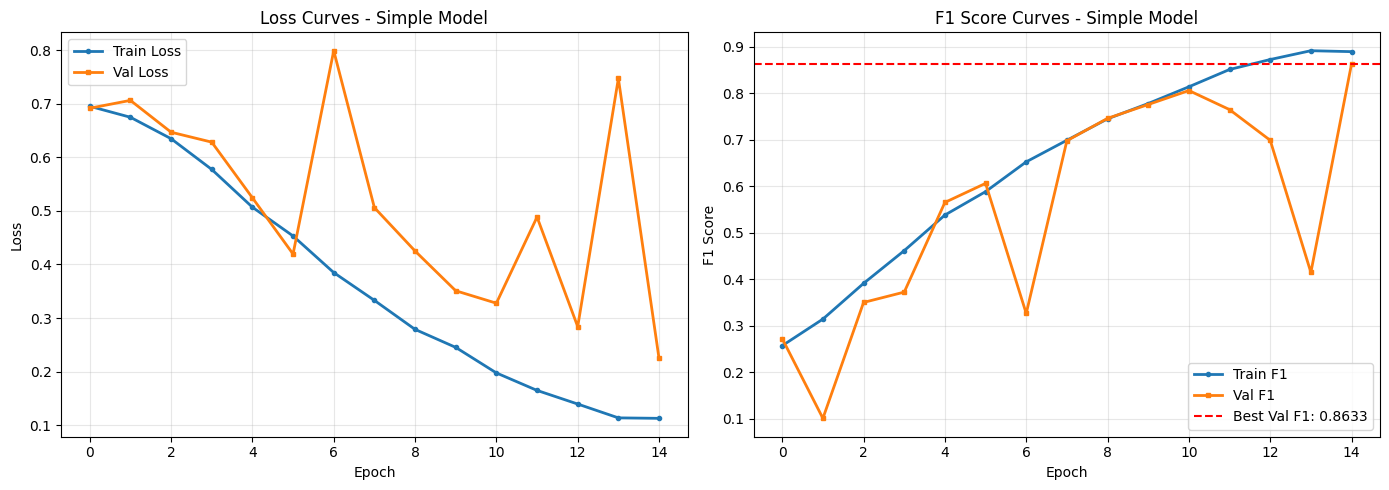


Графики сохранены: simple_training_curves.png


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_targets_full = targets[train_idx]
class_weights_np = compute_class_weight('balanced', classes=np.unique(train_targets_full), y=train_targets_full)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)

print(f"Используется устройство: {device}")
print(f"Class weights: {class_weights_np}")

model = SimpleFakeDetector(num_classes=2).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.SGD(model.parameters(), lr=0.02, momentum=0.95, weight_decay=1e-4, nesterov=True)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_val_f1 = 0.0
best_state = None
wait = 0

train_losses, val_losses = [], []
train_f1s, val_f1s = [], []

print("\n" + "="*70)
print("НАЧАЛО ОБУЧЕНИЯ ПРОСТОЙ МОДЕЛИ")
print("="*70)
print(f"Параметры обучения:")
print(f"  • Эпох: {NUM_EPOCHS}")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Patience для ранней остановки: {EARLY_STOP_PATIENCE}")
print(f"  • Сохранение чекпоинтов: каждые 5 эпох")
print("="*70 + "\n")

total_start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start_time = time.time()

    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_f1 = evaluate(model, val_loader, loss_fn, device)

    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start_time

    avg_epoch_time = (time.time() - total_start_time) / epoch
    remaining_epochs = NUM_EPOCHS - epoch
    estimated_remaining = avg_epoch_time * remaining_epochs

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(f"\n Эпоха {epoch:2d}/{NUM_EPOCHS} | Время: {format_time(epoch_time)}")
    print(f"  Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val F1:   {val_f1:.4f}")
    print(f"  LR: {current_lr:.6f} | Осталось ~{format_time(estimated_remaining)}")

    scheduler.step(val_f1)

    is_best = val_f1 > best_val_f1
    if is_best:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
        print(f"  НОВЫЙ РЕКОРД! Val F1: {best_val_f1:.4f}")
        save_checkpoint(model, optimizer, epoch, val_f1, is_best=True)
    else:
        wait += 1
        print(f"  Без улучшений: {wait}/{EARLY_STOP_PATIENCE}")

        if epoch % 5 == 0:
            save_checkpoint(model, optimizer, epoch, val_f1, is_best=False)

        if wait >= EARLY_STOP_PATIENCE:
            print(f"\nРанняя остановка на эпохе {epoch} (нет улучшений {EARLY_STOP_PATIENCE} эпох)")
            break

total_time = time.time() - total_start_time
print("\n" + "="*70)
print(f"ОБУЧЕНИЕ ЗАВЕРШЕНО за {format_time(total_time)}")
print(f"Лучший Val F1: {best_val_f1:.4f}")
print("="*70)

if best_state is not None:
    model.load_state_dict(best_state)
model.to(device)

torch.save(model.state_dict(), 'simple_model_weights.pth')
print(f"\nФинальная модель сохранена: simple_model_weights.pth")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2, marker='o', markersize=3)
axes[0].plot(val_losses, label='Val Loss', linewidth=2, marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves - Simple Model')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_f1s, label='Train F1', linewidth=2, marker='o', markersize=3)
axes[1].plot(val_f1s, label='Val F1', linewidth=2, marker='s', markersize=3)
axes[1].axhline(y=best_val_f1, color='r', linestyle='--', label=f'Best Val F1: {best_val_f1:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score Curves - Simple Model')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('simple_training_curves.png', dpi=150)
plt.show()

print(f"\nГрафики сохранены: simple_training_curves.png")

In [ ]:
holdout_probs = get_probs(model, holdout_loader, device)
np.save('holdout_probs_simple1.npy', holdout_probs)

test_probs = get_probs(model, test_loader, device)
np.save('test_probs_simple1.npy', test_probs)

from google.colab import files
#files.download('holdout_probs_simple1.npy')
#files.download('test_probs_simple1.npy')
files.download('simple_training_curves.png')

Predicting:   0%|          | 0/40 [00:00<?, ?it/s]

Predicting:   0%|          | 0/79 [00:00<?, ?it/s]

✅ ГОТОВО!
  - holdout_probs_simple.npy
  - test_probs_simple.npy


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Сложная модель для ансамбля
SEED = 444, Skip-connections, SE-блоки, Depthwise Separable, Label Smoothing, Adam

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score
from torch.amp import GradScaler, autocast
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import WeightedRandomSampler

!pip install gdown -q
import gdown
import zipfile

file_id = "1MCo9EhnTyW8qPJvIHlgS4_kmRyylvVV4"
url = f"https://drive.google.com/uc?id={file_id}"
output = "/content/ml-intensive.zip"
gdown.download(url, output, quiet=False)

with zipfile.ZipFile('/content/ml-intensive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

targets = pd.read_csv('/content/dataset/dataset/train_solution.csv', header=None)[1].values

class BaseDataset(Dataset):
    def __init__(self, img_dir, targets, transform=None):
        self.img_dir = img_dir
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.targets[idx], dtype=torch.long)

Downloading...
From (original): https://drive.google.com/uc?id=1MCo9EhnTyW8qPJvIHlgS4_kmRyylvVV4
From (redirected): https://drive.google.com/uc?id=1MCo9EhnTyW8qPJvIHlgS4_kmRyylvVV4&confirm=t&uuid=75648e4e-1671-4de2-92fb-d67719de4ca5
To: /content/ml-intensive.zip
100%|██████████| 2.68G/2.68G [00:25<00:00, 104MB/s]


In [ ]:
train_idx = np.load('/content/train_idx.npy')
holdout_idx = np.load('/content/holdout_idx.npy')

In [ ]:
SEED = 444
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.global_avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, padding=padding, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

class AdvancedBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_se=True):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(in_channels, out_channels)
        self.conv2 = DepthwiseSeparableConv(out_channels, out_channels)
        self.se = SEBlock(out_channels) if use_se else nn.Identity()

        self.skip = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.se(x)
        return F.relu(x + identity)

class AdvancedFakeDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block1 = AdvancedBlock(32, 64, use_se=True)
        self.pool1 = nn.MaxPool2d(2)

        self.block2 = AdvancedBlock(64, 128, use_se=True)
        self.pool2 = nn.MaxPool2d(2)

        self.block3 = AdvancedBlock(128, 256, use_se=True)
        self.pool3 = nn.MaxPool2d(2)

        self.block4 = AdvancedBlock(256, 512, use_se=True)
        self.pool4 = nn.MaxPool2d(2)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.initial(x)
        x = self.block1(x)
        x = self.pool1(x)
        x = self.block2(x)
        x = self.pool2(x)
        x = self.block3(x)
        x = self.pool3(x)
        x = self.block4(x)
        x = self.pool4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.85, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

BATCH_SIZE = 128
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3

In [ ]:
full_dataset = BaseDataset('/content/dataset/dataset/train_images', targets)

train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
train_dataset.dataset.transform = train_transforms

holdout_dataset = torch.utils.data.Subset(full_dataset, holdout_idx)
holdout_dataset.dataset.transform = val_transforms

val_split = int(0.9 * len(train_dataset))
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [val_split, len(train_dataset) - val_split],
    generator=torch.Generator().manual_seed(SEED)
)

train_targets_full = targets[train_idx]
train_targets_subset = train_targets_full[train_subset.indices]

class_counts = np.bincount(train_targets_subset)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_targets_subset]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=sampler,
                         num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=True)
holdout_loader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

class TestDataset(Dataset):
    def __init__(self, img_dir, num_images, transform=None):
        self.img_dir = img_dir
        self.num_images = num_images
        self.transform = transform
    def __len__(self):
        return self.num_images
    def __getitem__(self, idx):
        img = Image.open(f'{self.img_dir}/{idx}.jpg').convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, f'{idx}.jpg'

num_test = 10000
test_dataset = TestDataset('/content/dataset/dataset/test_images', num_test,
                           transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Class distribution in train_subset:")
print(f"Class 0: {(train_targets_subset == 0).sum()} ({100*(train_targets_subset == 0).sum()/len(train_targets_subset):.1f}%)")
print(f"Class 1: {(train_targets_subset == 1).sum()} ({100*(train_targets_subset == 1).sum()/len(train_targets_subset):.1f}%)")
print(f"Sample weights - class 0: {class_weights[0]:.3f}, class 1: {class_weights[1]:.3f}")

Class distribution in train_subset:
Class 0: 33598 (83.0%)
Class 1: 6902 (17.0%)
Sample weights - class 0: 0.000, class 1: 0.000


In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for x, y in tqdm(loader, desc='Train'):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler:
            with autocast('cuda'):
                output = model(x)
                loss = loss_fn(output, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            output = model(x)
            loss = loss_fn(output, y)
            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    for x, y in tqdm(loader, desc='Eval'):
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = loss_fn(output, y)
        total_loss += loss.item()
        all_preds.append(output.argmax(1).cpu())
        all_labels.append(y.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return total_loss / len(loader), f1

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = AdvancedFakeDetector(num_classes=2).to(device)
loss_fn = FocalLoss(alpha=0.85, gamma=2.5)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
scaler = GradScaler('cuda') if device.type == 'cuda' else None

best_val_f1 = 0.0
best_state = None
wait = 0
patience = 10

print("Начинаем обучение сложной модели с Focal Loss и Weighted Sampler...")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, optimizer, loss_fn, device, scaler)
    val_loss, val_f1 = evaluate(model, val_loader, loss_fn, device)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | Val Loss: {val_loss:.4f} F1: {val_f1:.4f} | LR: {current_lr:.6f}")

    scheduler.step(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
        print(f"  -> Новая лучшая модель! F1: {best_val_f1:.4f}")
    else:
        wait += 1
        if wait >= patience:
            print(f"Ранняя остановка на эпохе {epoch}")
            break

if best_state is not None:
    model.load_state_dict(best_state)
model.to(device)

torch.save(model.state_dict(), 'model_weights_hard.pth')
print(f"Веса модели сохранены. Лучший Val F1: {best_val_f1:.4f}")

Начинаем обучение сложной модели с Focal Loss и Weighted Sampler...


Eval: 100%|██████████| 36/36 [00:11<00:00,  3.15it/s]


Epoch  1 | Train Loss: 0.0942 F1: 0.6388 | Val Loss: 0.0735 F1: 0.5399 | LR: 0.001000
  -> Новая лучшая модель! F1: 0.5399


Eval: 100%|██████████| 36/36 [00:11<00:00,  3.06it/s]


Epoch  2 | Train Loss: 0.0602 F1: 0.8339 | Val Loss: 0.0375 F1: 0.7138 | LR: 0.001000
  -> Новая лучшая модель! F1: 0.7138


...

Epoch 28 | Train Loss: 0.0010 F1: 0.9981 | Val Loss: 0.0384 F1: 0.8577 | LR: 0.000250


Eval: 100%|██████████| 36/36 [00:11<00:00,  3.09it/s]


Epoch 29 | Train Loss: 0.0012 F1: 0.9978 | Val Loss: 0.0209 F1: 0.9164 | LR: 0.000250
  -> Новая лучшая модель! F1: 0.9164


Eval: 100%|██████████| 36/36 [00:11<00:00,  3.09it/s]

Epoch 30 | Train Loss: 0.0007 F1: 0.9988 | Val Loss: 0.0224 F1: 0.9126 | LR: 0.000250
Веса модели сохранены. Лучший Val F1: 0.9164


In [ ]:
@torch.no_grad()
def get_probs(model, loader, device):
    model.eval()
    probs = []
    for x, _ in tqdm(loader, desc='Predicting'):
        x = x.to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(prob)
    return np.concatenate(probs)

holdout_probs = get_probs(model, holdout_loader, device)
np.save('holdout_probs_ultra_hard.npy', holdout_probs)

test_probs = get_probs(model, test_loader, device)
np.save('test_probs_ultra_hard.npy', test_probs)

print("Готово! Файлы:")
print("- holdout_probs_ultra_hard.npy")
print("- test_probs_ultra_hard.npy")

from google.colab import files
files.download('holdout_probs_ultra_hard.npy')
files.download('test_probs_ultra_hard.npy')

Predicting: 100%|██████████| 79/79 [00:23<00:00,  3.31it/s]

Готово! Файлы:
- holdout_probs_ultra_hard.npy
- test_probs_ultra_hard.npy


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Мета-модель



Мета-модель: стекинг logistic regression + lightgbm
SEED = 42

Логика:
1. Берём вероятности от 7 базовых моделей на холдауте, получаем из этого матрицу признаков
2. Обучаем две мета-модели: логистическую регрессию и lightgbm
3. oof-предсказания обеих мета-моделей смешиваем линейно с весом w, порог подбираем по максимуму f1 на холдауте
4. Финальное предсказание на тесте получаем тем же смешиванием

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import lightgbm as lgb
import pickle

# Индексы холдаута
holdout_idx = np.load('holdout_idx.npy')

# Истинные метки холдаута
targets = pd.read_csv('/content/train_solution.csv', header=None)[1].values
y_holdout = targets[holdout_idx]

In [ ]:
# Загрузка предсказаний всех моделей на холдауте
probs_amir_simple = np.load('holdout_probs_amir_simple.npy')
probs_amir_hard = np.load('holdout_probs_amir_complex.npy')
probs_timur_simple = np.load('holdout_probs_timur_simple.npy')
probs_timur_vit = np.load('holdout_probs_timur_vit.npy')
probs_timur_hard = np.load('holdout_probs_timur_hard.npy')
probs_yana_simple = np.load('holdout_probs_simple1.npy')
probs_yana_hard = np.load('holdout_probs_ultra_hard.npy')

# Формируем матрицу мета-признаков
X_meta = np.column_stack([
    probs_amir_simple, probs_amir_hard,
    probs_timur_simple,
    probs_timur_vit, probs_timur_hard, probs_yana_simple, probs_yana_hard
])

# Для lightgbm нужны имена колонок
feature_names = [f'model_{i}' for i in range(X_meta.shape[1])]
X_meta_df = pd.DataFrame(X_meta, columns=feature_names)

In [ ]:
# Первая мета-модель - logistic regression
# Сильная регуляризация и вес редкого класса, чтобы не переобучиться на 7 признаках
# max_iter побольше, чтобы сошёлся

# Стратифицированная кросс-валидация на 3 фолдах
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Получаем oof-вероятности
oof_probs_lr = cross_val_predict(lr_best, X_meta, y_holdout, cv=cv, method='predict_proba')[:, 1]

# Обучаем logreg на всём холдауте
lr_best.fit(X_meta, y_holdout)

LogisticRegression(C=0.01, class_weight={0: 1, 1: 5}, max_iter=2000,
                   random_state=42)

In [ ]:
# Вторая мета-модель - lightgbm
# Маленькие деревья, сильная регуляризация, class_weight='balanced' – автоматический учёт дисбаланса.
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    num_leaves=4,
    max_depth=2,
    learning_rate=0.03,
    n_estimators=500,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=0.5,
    min_child_samples=50,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

# Получаем oof-вероятности
oof_probs_lgb = cross_val_predict(lgb_model, X_meta_df, y_holdout, cv=cv, method='predict_proba')[:, 1]

# Обучаем lgdm на всём холдауте
lgb_model.fit(X_meta_df, y_holdout)

LGBMClassifier(class_weight='balanced', colsample_bytree=0.7,
               learning_rate=0.03, max_depth=2, min_child_samples=50,
               n_estimators=500, num_leaves=4, objective='binary',
               random_state=42, reg_alpha=0.5, reg_lambda=0.5, subsample=0.7,
               verbosity=-1)

In [ ]:

best_w = 0.5
best_th = 0.5
best_f1_ens = 0.0


# Перебираем w (вес для logreg) от 0 до 1 и порог от 0.3 до 0.7,
# чтобы найти максимум f1 именно на кросс-валидационных предсказаниях
for w in np.linspace(0.0, 1.0, 21):
    ens_probs = w * oof_probs_lr + (1 - w) * oof_probs_lgb
    for th in np.linspace(0.3, 0.7, 100):
        preds = (ens_probs > th).astype(int)
        f1 = f1_score(y_holdout, preds)
        if f1 > best_f1_ens:
            best_f1_ens = f1
            best_w = w
            best_th = th

print(f"Лучший вес LR: {best_w:.2f} (LGBM: {1-best_w:.2f})")
print(f"Лучший порог: {best_th:.4f}")
print(f"OOF F1 ансамбля: {best_f1_ens:.5f}")

Лучший вес LR: 0.65 (LGBM: 0.35)
Лучший порог: 0.5465
OOF F1 ансамбля: 0.96225


In [ ]:
# Загрузка тестовых предсказаний
test_amir_simple = np.load('test_probs_amir_simple.npy')
test_amir_hard = np.load('test_probs_amir_complex.npy')
test_timur_simple = np.load('test_probs_timur_simple.npy')
test_timur_vit = np.load('test_probs_timur_vit.npy')
test_timur_hard = np.load('test_probs_timur_hard.npy')
test_yana_simple = np.load('test_probs_simple1.npy')
test_yana_hard = np.load('test_probs_ultra_hard.npy')

# Те же самые 7 признаков для теста
X_test_meta = np.column_stack([
    test_amir_simple, test_amir_hard,
    test_timur_simple, test_timur_vit, test_timur_hard,
    test_yana_simple, test_yana_hard
])
X_test_meta_df = pd.DataFrame(X_test_meta, columns=feature_names)

# Предсказания каждой мета-модели на тесте
test_probs_lr = lr_best.predict_proba(X_test_meta)[:, 1]
test_probs_lgb = lgb_model.predict_proba(X_test_meta_df)[:, 1]

# Финальное смешивание с оптимальными весом и порогом
final_probs = best_w * test_probs_lr + (1 - best_w) * test_probs_lgb
final_preds = (final_probs > best_th).astype(int)

print(f"Распределение предсказаний: {np.bincount(final_preds)}")

Распределение предсказаний: [8360 1640]


In [ ]:
# Создаем submission
test_ids = np.arange(len(final_preds))

submission = pd.DataFrame({
    'id': test_ids,
    'target_feature': final_preds
})
submission.to_csv('submission_ensemble5.csv', index=False)

In [ ]:
# Сохраняем обученные мета-модели и параметры для воспроизводимости
import pickle

with open('logistic_regression_meta.pkl', 'wb') as f:
    pickle.dump(lr_best, f)

with open('lightgbm_meta.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

ensemble_params = {
    'best_w': best_w,
    'best_th': best_th,
    'feature_names': feature_names
}
with open('ensemble_params.pkl', 'wb') as f:
    pickle.dump(ensemble_params, f)

# Итоги

Бинарная классификация изображений дипфейков с сильным
дисбалансом:

Класс 0 – 41500 объектов

Класс 1 – 8500 объектов

Целевая метрика – f1-score

---

Стратегия построения ансамбля:

Использовано 7 независимых моделей с разными архитектурными решениями и настройками обучения:

1.   Амир простая:	focal loss, adamw, стандартная cnn
2.   Амир сложная:	groupnorm, gem pooling, дополнительный частотный канал, focal loss, random erasing
3.   Яна простая:	crossentropyLoss, sgd, стандартная cnn
4.   Яна сложная:	skip-connections + se-блоки, label smoothing, depthwise свёртки, adam, аугментации
5.   Тимур простая: crossrntropyloss, базовая архитектура
6.   Тимур сложная: аугментация cutmix для улучшения обобщения
7.   Тимур vit: vision transformer для улавливания глобальных зависимостей

Каждая модель была обучена со своим seed, что добавляет разнообразие за счёт различной инициализации весов и порядка батчей

---

Cтейкинг:

Мета-признаки:

Вероятности принадлежности к классу 1, выданные семью базовыми моделями на холдаут выборке

Мета-модели:

Логистическая регрессия с усиленным весом класса 1 для коррекции дисбаланса

lightgbm с ограниченной глубиной

Ансамбль второго уровня: линейная комбинация предсказаний logreg и lgbm с весами, оптимизированными по f1 на oof прогнозах

---
Итог:

Учёт дисбаланса повышает влияние миноритарного класса. Разнообразие базовых моделей, а так же использование как свёрточных, так и трансформерной моделей позволяют ошибаться на разных участках данных, что увеличивает эффект от ансамблирования

Перебор порога для ансамбля на OOF выборке смещает баланс между точностью и полнотой в пользу лучшего f1

f1-score = 0.97482 на скрытой тестовой выборкe - неплохой результат

Распределение предсказаний показывает, что модель хорошо выделяет дипфейки без большого количества ложных срабатываний

---

Направление дальнейших улучшений:

Кросс-валидационное обучение базовых моделей:
вместо однократного обучения каждой модели на фиксированном разбиении используется stratifiedkfold для получения OOF предсказаний на всех тренировочных данных